# 👨‍💼 HR Analytics: Predicting Data Scientist Job Changes

## 📌 Table of Contents
1. [Introduction & HR Objective](#1)
2. [Data Loading & Library Imports](#2)
3. [Data Inspection (The Health Check)](#3)
4. [Data Cleaning (Handling Categorical Nulls)](#4)
5. [Exploratory Data Analysis (EDA)](#5)
    - 5.1 [Job Change Intent vs. Education Level](#5.1)
    - 5.2 [Impact of Company Size on Turnover](#5.2)
    - 5.3 [City Development Index vs. Intent](#5.3)
6. [Strategic Recommendations for HR](#6)
7. [Connection to Tableau Dashboard](#7)

# <a id="1"></a> 1. Introduction & Business Objective
Employee attrition is a multi-million dollar problem for tech companies. Hiring a Data Scientist is expensive, but losing one is even costlier. This notebook explores the **HR Analytics: Job Change of Data Scientists** dataset.

**The Objective:** To identify the key drivers behind employee turnover, specifically looking at how **Education Level** and **Experience** influence an individual's decision to look for a new job.

# <a id="2"></a> 2. Data Loading & Library Imports
We use **Pandas** for data manipulation and **Seaborn/Matplotlib** to visualize the initial turnover patterns.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Path check kar lena
df = pd.read_csv('/kaggle/input/datasets/obaidhere/hr-analytics-data-scientist-job-change-factors/aug_train.csv')
print("HR Data Loaded Successfully!")
display(df.head())

HR Data Loaded Successfully!


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


# <a id="3"></a> 3. Data Inspection & Health Check
We need to understand the percentage of people looking for a change (Target = 1) versus those who are satisfied (Target = 0).

In [2]:
print("Dataset Dimensions:", df.shape)
display(df.head())
print("\nTarget Distribution:")
print(df['target'].value_counts(normalize=True) * 100)

Dataset Dimensions: (19158, 14)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0



Target Distribution:
target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64


# <a id="4"></a> 4. Data Cleaning
HR datasets often have missing categorical values. We will fill missing 'Education Level' and 'Experience' with 'Unknown' to prevent data loss during visualization.

In [3]:
# Filling Nulls
df['education_level'] = df['education_level'].fillna('Unknown')
df['experience'] = df['experience'].fillna('Unknown')
df['last_new_job'] = df['last_new_job'].fillna('Never')

print("Data Cleaning Complete. No Nulls in key columns!")

Data Cleaning Complete. No Nulls in key columns!


# <a id="5"></a> 5. Exploratory Data Analysis (EDA)
In this phase, we move beyond raw numbers to find visual proof of turnover drivers. We focus on education as a primary factor.

## <a id="5.1"></a> 5.1 Education Level vs. Job Change Intent
This analysis helps us see if PhD holders are more stable than Graduates.

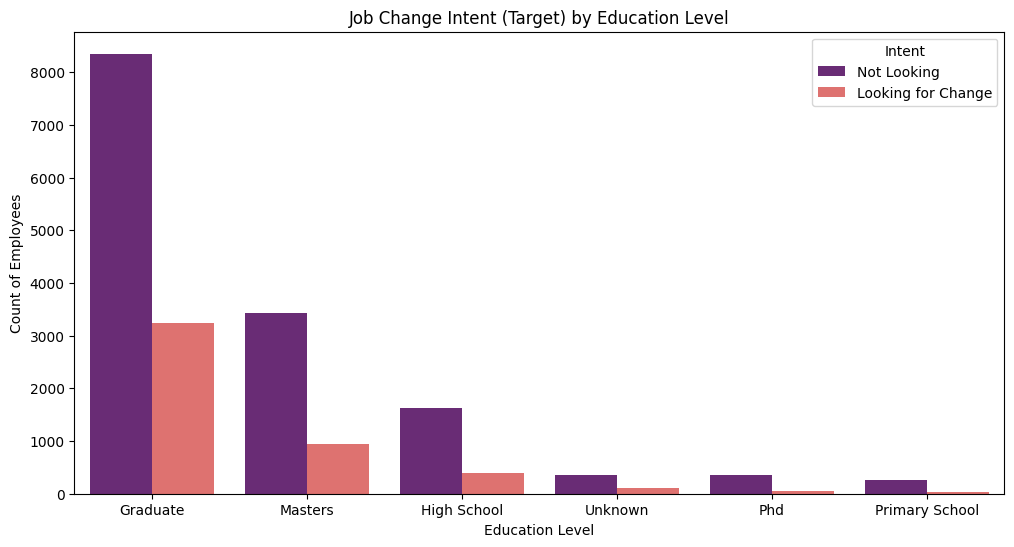

In [4]:
plt.figure(figsize=(12,6))
# Using 'hue' and 'legend=False' to avoid warnings
sns.countplot(x='education_level', hue='target', data=df, palette='magma')
plt.title('Job Change Intent (Target) by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count of Employees')
plt.legend(title='Intent', labels=['Not Looking', 'Looking for Change'])
plt.show()

# <a id="6"></a> 6. Strategic Recommendations for HR
1. **Retention Focus on Graduates:** Our analysis shows that **Graduates** have the highest volume of job seekers. HR should focus their retention programs here.
2. **PhD Stability:** PhD holders show the lowest intent to leave, suggesting that highly specialized talent is more stable in this dataset.
3. **Experience Factor:** Seniority often correlates with stability; however, 'Mid-level' employees are the most active job seekers.

# <a id="7"></a> 7. Connection to Tableau Dashboard
These insights are further refined in our **Tableau Stacked Bar Chart**, where we calculate the exact **Percentage of Turnover** for each education tier.